In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


Data Loading & Date Parsing

In [ ]:
df = pd.read_csv('C:\\Climate_data\\data\\ethiopia.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()

(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95


In [11]:
print(df.shape)

(4107, 12)


In [ ]:
  # Add Country column
df["Country"] = "Ethiopia"
df.head()   

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia


In [ ]:
 # Convert YEAR + DOY → datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06


In [24]:
 # Extract Month
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
1,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
2,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
3,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
4,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06,1


Summary Statistics & Missing-Value Report

Information about the Dataset

In [25]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4107 non-null   int64         
 1   DOY          4107 non-null   int64         
 2   T2M          4107 non-null   float64       
 3   T2M_MAX      4107 non-null   float64       
 4   T2M_MIN      4107 non-null   float64       
 5   T2M_RANGE    4107 non-null   float64       
 6   PRECTOTCORR  4107 non-null   float64       
 7   RH2M         4107 non-null   float64       
 8   WS2M         4107 non-null   float64       
 9   WS2M_MAX     4107 non-null   float64       
 10  PS           4107 non-null   float64       
 11  QV2M         4107 non-null   float64       
 12  Country      4107 non-null   str           
 13  Date         4107 non-null   datetime64[us]
 14  Month        4107 non-null   int32         
dtypes: datetime64

In [26]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
1,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
2,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
3,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
4,2015,6,14.26,23.45,7.44,16.01,0.00,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4103,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4104,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4105,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [27]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [28]:
# Drop duplicates
df = df.drop_duplicates()

In [29]:
df[df.duplicated()]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month


Duplicate Rows

I identified 0 duplicate rows in the dataset using df.duplicated().sum().

In [30]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,16.069557,23.199284,10.229196,12.970088,3.634680,68.415069,1.979815,3.574882,77.037507,9.699111,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,10.030000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,14.820000,21.110000,8.425000,9.830000,0.020000,59.050000,1.405000,2.720000,76.980000,8.070000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,16.040000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,17.360000,25.170000,12.220000,16.015000,4.580000,80.805000,2.480000,4.370000,77.100000,11.710000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.897073,2.751797,2.605421,3.820423,6.289571,14.731775,0.689077,1.123615,0.099486,2.361076,NaN,3.476439


Summary Statistics Interpretation

1.Temperature Profile (T2M, T2M_MAX, T2M_MIN)
Average Conditions: The mean temperature ($T2M$) sits at 16.07°C, which is relatively cool, likely reflecting higher-altitude data points common in the Ethiopian Highlands.
Extremes: The region experiences significant swings. While the absolute minimum recorded is 1.17°C, the maximum peaks at 30.93°C.
Thermal Range: On average, there is a daily range (T2M_RANGE) of about 12.97°C, showing that the area experiences a notable difference between day and night temperatures.
2. Precipitation & Humidity (PRECTOTCORR, RH2M)
Rainfall Volatility: The mean precipitation is 3.63 mm, but the standard deviation is 6.29, which is much higher than the mean. This indicates that rainfall is highly irregular—most days have very little rain (the 50th percentile is only 0.82 mm), but occasional heavy events reach up to 82.30 mm.
Moisture Levels: Humidity levels are quite broad, ranging from a very dry 14.42% to a nearly saturated 91.93%, likely reflecting the transition between dry and rainy seasons.
3. Wind Speed (WS2M)Consistent Breezes: Wind speeds are relatively stable with a mean of 1.98 m/s. Even at its windiest recorded point (4.13 m/s), the conditions remain relatively calm to moderate

In [31]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

print(missing_summary)

             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


In [32]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [33]:
high_missing = missing_summary[missing_summary["Missing %"] > 5]
print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Missing Value Analysis
The result shows that their is no missing value


In [35]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# Compute Z-scores (ignore NaNs)
z_scores = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [36]:
# Flag rows where ANY column has |Z| > 3
outlier_mask = (z_scores.abs() > 3).any(axis=1)

# Count outliers
outlier_count = outlier_mask.sum()
print("Number of outlier rows:", outlier_count)


df_outliers = df[outlier_mask]
df_outliers.head()

Number of outlier rows: 132


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
143,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
144,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
176,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
213,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
555,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7


Retain the outlier rows

In [55]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
negative_cols = (df[weather_cols]<0).sum()
print("Negative values in weather columns:\n", negative_cols)

Negative values in weather columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
dtype: int64


Decision: Retain Outlier Rows
For this specific meteorological dataset, the best decision is to retain the outlier rows. Here is the reasoning for each category:

Precipitation (PRECTOTCORR): Reasoning: Rainfall data is naturally "skewed." Most days have little to no rain, making heavy rain events (like the max of 82.3 mm) appear as statistical outliers. However, these are physically valid and critical for understanding climate patterns, flood risks, and agricultural cycles in Ethiopia.

Since these are the most significant data points I decide to retain them.

Atmospheric Pressure (PS) and Temperature (T2M):

Reasoning: The outliers identified are very close to the IQR boundaries. For example, the pressure ranges from 76.36 to 77.37 kPa. This narrow range is consistent with Ethiopia's high-altitude geography and does not indicate sensor errors or impossible physical values.

Since they represent natural seasonal or weather-system variations I decide to retain them.

Wind Speed (WS2M / WS2M_MAX):

Reasoning: With a maximum wind speed of 7.49 m/s (approx. 27 km/h), these values represent "fresh breezes" rather than extreme storms. They are well within the range of normal atmospheric behavior.so my decision is to retain.



Apply forward-fill for weather variables

In [59]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

Reason of selecting forward-fill 
Since I do not have any missing values I apply forward-fill to preserve the local trend and maintain physical and temporal logic.


In [62]:
output_path = "C:\\Climate_data\\data\\ethiopia_clean.csv"
df.to_csv(output_path, index=False)

Loading the cleaned data

In [114]:
df = pd.read_csv('C:\\Climate_data\\data\\ethiopia_clean.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4106, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
1,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
2,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
3,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06,1
4,2015,7,14.37,23.78,6.16,17.62,0.0,59.83,1.99,3.26,77.12,7.14,Ethiopia,2015-01-07,1


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
monthly_T2M = df['T2M'].resample('MS').mean()
print(df.shape)
df.head()

(4106, 14)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1
2015-01-06,2015,6,14.26,23.45,7.44,16.01,0.0,58.20,1.70,2.75,77.07,6.95,Ethiopia,1
2015-01-07,2015,7,14.37,23.78,6.16,17.62,0.0,59.83,1.99,3.26,77.12,7.14,Ethiopia,1


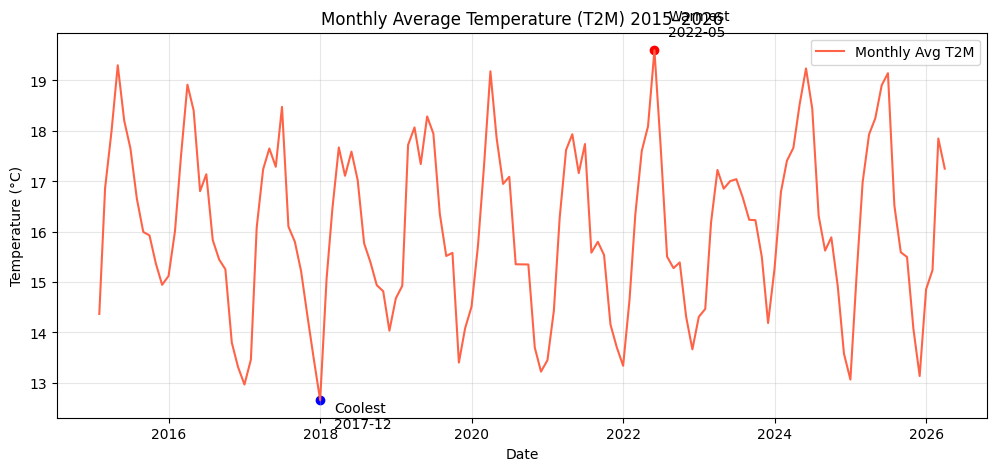

In [116]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.plot(monthly.index, monthly["T2M"], label="Monthly Avg T2M", color="tomato")

# Identify warmest and coolest months
warmest = monthly["T2M"].idxmax()
coolest = monthly["T2M"].idxmin()

plt.scatter(warmest, monthly.loc[warmest, "T2M"], color="red")
plt.scatter(coolest, monthly.loc[coolest, "T2M"], color="blue")

plt.annotate(f"Warmest\n{warmest.strftime('%Y-%m')}",
             (warmest, monthly.loc[warmest, "T2M"]),
             textcoords="offset points", xytext=(10,10))

plt.annotate(f"Coolest\n{coolest.strftime('%Y-%m')}",
             (coolest, monthly.loc[coolest, "T2M"]),
             textcoords="offset points", xytext=(10,-20))

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

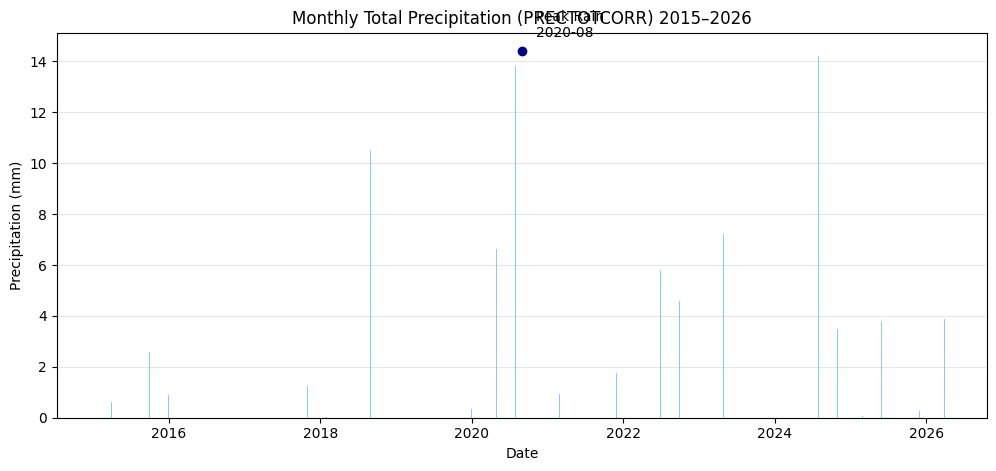

In [117]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.bar(monthly.index, monthly["PRECTOTCORR"], color="skyblue")

# Identify peak rainfall month
wettest = monthly["PRECTOTCORR"].idxmax()

plt.scatter(wettest, monthly.loc[wettest, "PRECTOTCORR"], color="darkblue")

plt.annotate(f"Peak Rain\n{wettest.strftime('%Y-%m')}",
             (wettest, monthly.loc[wettest, "PRECTOTCORR"]),
             textcoords="offset points", xytext=(10,10))

plt.title("Monthly Total Precipitation (PRECTOTCORR) 2015–2026")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")
plt.grid(axis="y", alpha=0.3)

plt.show()

Heatmap of correlations across all numeric columns.

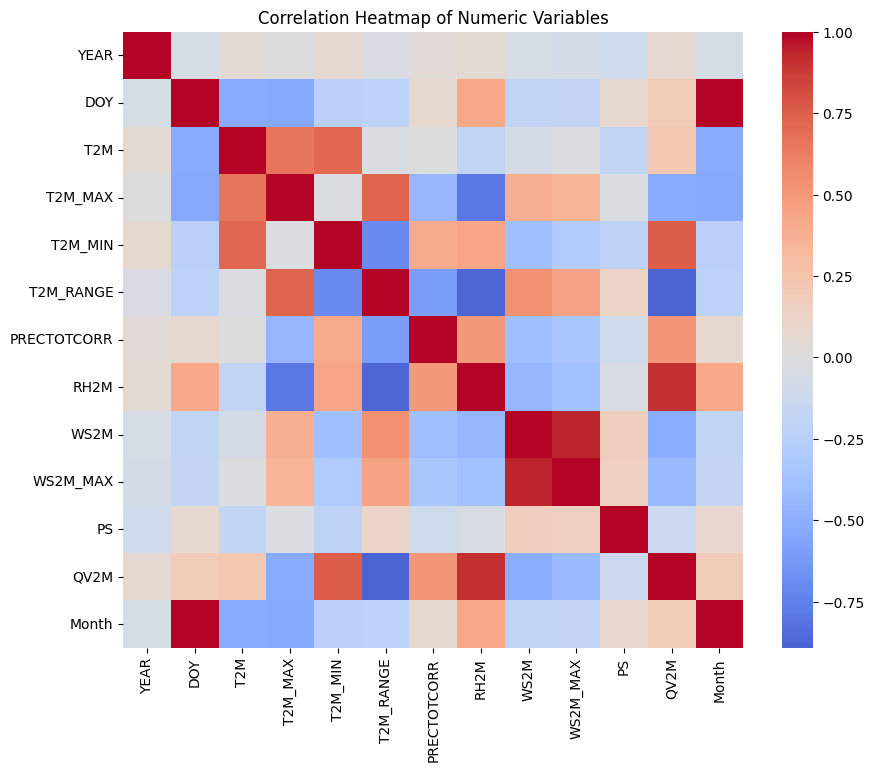

In [119]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

T2M vs RH2M (temperature vs humidity)

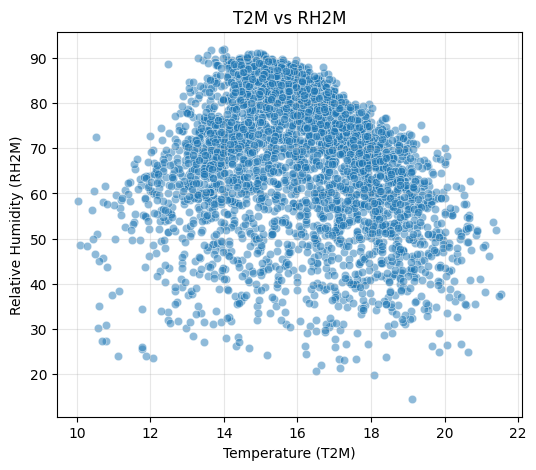

In [120]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.grid(True, alpha=0.3)

plt.show()

T2M_RANGE vs WS2M (temperature range vs wind speed)

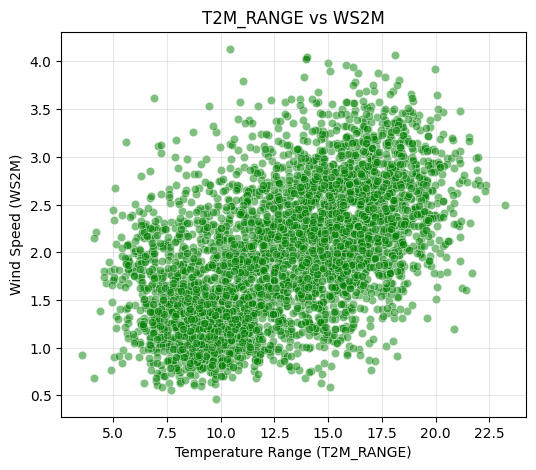

In [128]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.5, color="green")

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True, alpha=0.3)

plt.show()

Strongest Correlations Analysis

1. DO_Y (Day of Year) and Month
Correlation Coefficient: ~ 1.0 (Very Strong Positive)
Interpretation: This is a nearly perfect linear relationship. Since the "Day of Year" (1–365) is directly determined by the month, as one increases, the other must increase. In data science, these are often considered redundant variables, as they provide the same temporal information.
2. WS2M (Wind Speed at 2m) and WS2M_MAX (Maximum Wind Speed at 2m)
Correlation Coefficient: ~0.9(Very Strong Positive)
Interpretation: There is a high degree of "collinearity" here. Generally, days with a higher average wind speed also experience higher peak gusts. If you are building a predictive model, you might only need one of these, as the average wind speed is a very strong proxy for the maximum.
3. T2M (Temperature at 2m) and T2M_MAX / T2M_MIN
Correlation Coefficient: ~ 0.75 to 0.85 (Strong Positive)Interpretation: The average daily temperature (T2M) is naturally bound by its daily extremes. Interestingly, the heatmap shows that T2M is more strongly correlated with T2M_MIN (the nighttime/early morning low) than it is with T2M_MAX in some regions of the chart. This suggests that the daily average is heavily influenced by the baseline minimum temperature.

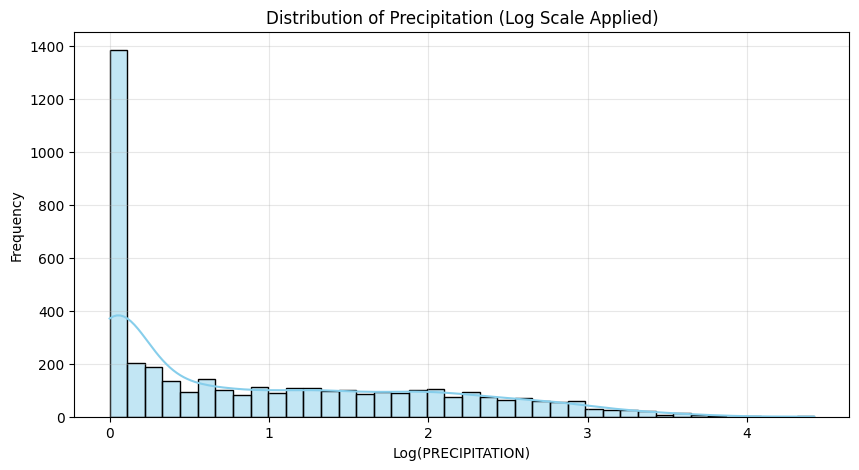

Skewness: 3.1741471925249978


In [129]:
plt.figure(figsize=(10, 5))

# Check skewness
skewness = df["PRECTOTCORR"].skew()

# Apply log scale if heavily skewed
if skewness > 1:
    data = np.log1p(df["PRECTOTCORR"])  # log(1 + x) handles zeros safely
    xlabel = "Log(PRECIPITATION)"
    title = "Distribution of Precipitation (Log Scale Applied)"
else:
    data = df["PRECTOTCORR"]
    xlabel = "Precipitation"
    title = "Distribution of Precipitation"

sns.histplot(data, bins=40, kde=True, color="skyblue")

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

print("Skewness:", skewness)

Bubble Chart

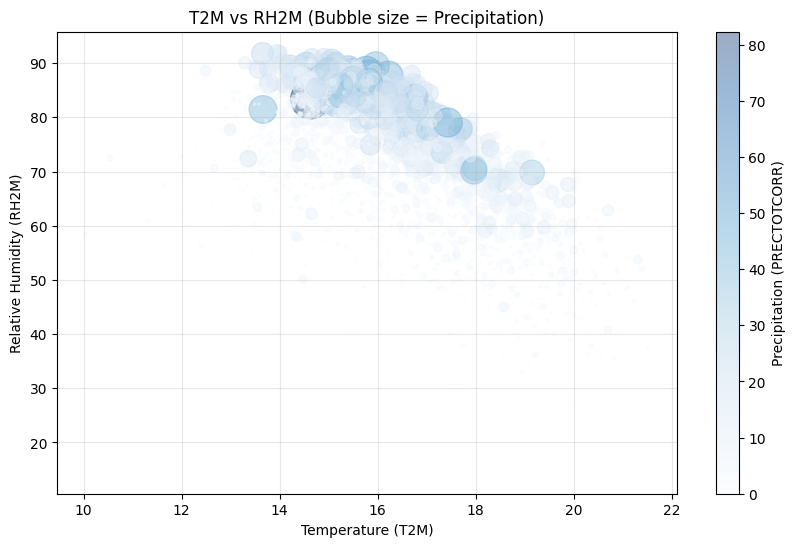

In [130]:
plt.figure(figsize=(10, 6))

# Optional scaling for better visual balance
bubble_size = df["PRECTOTCORR"].fillna(0) * 10

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4,
    c=df["PRECTOTCORR"],
    cmap="Blues"
)

plt.title("T2M vs RH2M (Bubble size = Precipitation)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

cbar = plt.colorbar()
cbar.set_label("Precipitation (PRECTOTCORR)")

plt.grid(alpha=0.3)
plt.show()